# RPCA-based Risk Modeling for Portfolio Optimization


## An Unsupervised, Spectral ML Approach

Какие-нибудь тексты

# -I.) Формулы и описание Linear constrained quadratic optimization

Формулы из учебника


# 0.) Графики и визуализации

- вставить график "/home/dimitri/Social-processes/Make-Up/weight_change_l1_norm_timeseries_200.png" из папки "/home/dimitri/Social-processes/Make-Up/"
- показать cond_number = **np.linalg.cond(Sigma)**  # condition number of Σ

<img src="../Make-Up/weight_change_l1_norm_timeseries_200.png" alt="Изменение веса L1 нормы" style="width:70%; height:auto;"/>



Где-то тут на выходе:

 `../detrended_returns_df_200.csv` - $X∈R^{T×N}$  — «исходные» детренд-лог-доходности, которые загружаются для Шага 1. Это именно тот объект, который затем центрируется и масштабируется.

# I. Центровка по столбцам (Step 1)

 DataFrame `detrended_returns_df` := $X∈R^{T×N}$  — «исходные» детренд-лог-доходности, которые загружаются из файла `../detrended_returns_df_200.csv`. Это именно тот объект, который затем центрируется и масштабируется.

## Почему:
- средние по столбцам за окно почти никогда не равны нулю точно (есть остаточный дрейф/смещение, особенно на коротких окнах).
- В RPCA постоянные смещения по столбцу дают лишний ранг-1 вклад и ухудшают контроль ранга низкоранговой части 𝐿.
- Робастная центровка (лучше медиана, чем среднее) делает модель более устойчивой, а разрежённая часть 𝑆 начинает «ловить» именно всплески/аномалии вокруг нулевой базы.

In [107]:
%run robust_PCA_step1.py

Sanity — |column median| after centering (should be ~0):
count    188.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
dtype: float64

[INFO] Step 1 (centering). Files saved:
 - returns_centered.parquet
 - center_shift_vector.csv


`center_shift_vector.csv` - вектор $m∈𝑅^𝑁$ — вектор сдвигов (медианы столбцов)

# II. Масштабирование по столбцам (Step 2)

## Почему:
- RPCA штрафует элементы матрицы равномерно; если волатильности активов сильно различаются (а в реальности так и есть), то без масштабирования активы с большой дисперсией «доминируют» в штрафах, и разрежённость 𝑆/ранг 𝐿 подстраиваются под масштаб, а не под структуру.
- Приведение столбцов к единому масштабу делает штрафы сопоставимыми между активами и улучшает восстановление низко ранговой структуры.
## Чем масштабировать:
- Лучше робастной шкалой: MAD (median absolute deviation). MAD (Median Absolute Deviation)  — это робастная мера “размаха” (масштаба) данных. Считается как медиана абсолютных отклонений наблюдений от робастного центра (обычно от медианы столбца):

MAD = median(|xᵢ − median(x)|).

В отличие от стандартного отклонения, MAD почти не “ломается” на выбросах и тяжёлых хвостах, поэтому подходит для финансовых рядов.

In [108]:
%run robust_PCA_step2.py


Sanity — robust spread (MAD*1.4826) after scaling (~1 expected):
count    1.880000e+02
mean     1.000000e+00
std      2.812419e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

[INFO] Step 2 (scaling) completed. Files saved:
 - returns_centered_scaled.parquet
 - scale_vector.csv


## Что мы получили после
`scaled_df, scale_vec = scale_columns_mad(centered_df, mad_consistency=1.4826)` — и зачем это сделали

`mad_consistency: float = 1.4826` - это Константа — коэффициент “приведения к сопоставимой шкале со стандартным отклонением” при нормальном распределении. У стандартной нормали медиана |Z| ≈ 0.67449, поэтому $σ ≈ \frac{MAD}{0.67449} ≈ 1.4826⋅MAD$.
## Зачем:
- Сделать штрафы RPCA сопоставимыми между активами (без этого высоковолатильные активы доминируют в оптимизации).
- Упростить извлечение структуры: RPCA лучше выделяет низкоранговую часть (общерыночные/секторные компоненты) и разрежённые всплески, когда колонкам придан схожий масштаб.
- Сохраняем обратимость: благодаря `scale_vec` (и ранее сохранённому `shift_vec`) можно вернуться в исходные единицы после RPCA, чтобы корректно строить ковариации и портфели.

Итого, я реализовал:
$$X_{cs} = (X − 1m^⊤)D^{−1},$$ где $m∈𝑅^𝑁$ — вектор сдвигов (медианы столбцов),
$D = diag(s_1, …, s_N)$ — диагональная матрица робастных масштабов.

`scale_vector.csv` - вектор масштабов $s = (s_1, …, s_N)$ для обратного масштабирования столбцов. Этот вектор нужен для воссоздания диагональной матрицы $D = diag((s_1, …, s_N)  ∈ 𝑅^{𝑁×𝑁}, s_i = c_{MAD}⋅MAD_i$ (с $c_{MAD} ≈ 1.4826$).

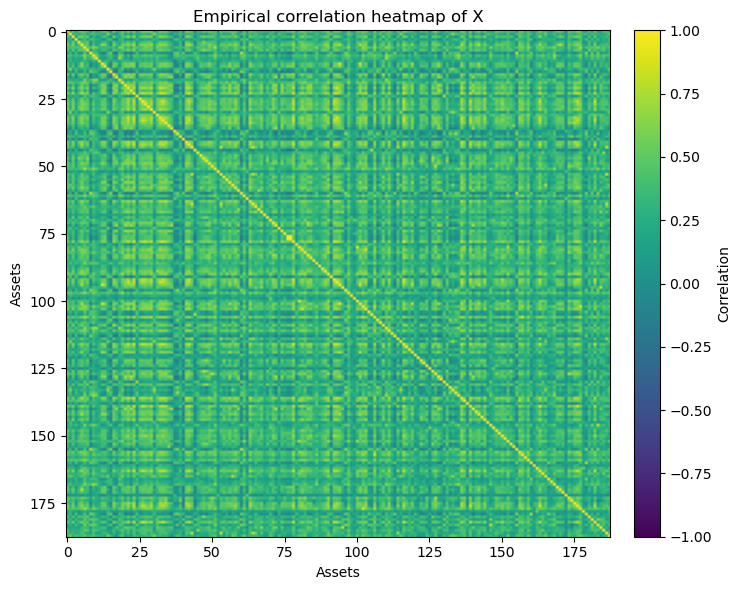

<Figure size 640x480 with 0 Axes>

In [109]:
%run plot_corr_empirical.py

# III. Step 3: R-PCA (ADMM)

## III.1) Постановка R-PCA (Principal Component Pursuit)
1.1) Целевая задача «Principal Component Pursuit» (каноническая форма):

$\underset{L,S}{\text{min}} \|L\|_* + \lambda \|S\|_1 \text{ при } X_{cs} = L + S$, при $X_{cs} = L + S,$

где

- $ X_{cs} \in R^{T \times N} $ — центрированно-масштабированные доходности,
- $∥L∥_∗=∑_iσ_i(L)$ — ядерная норма (сумма сингулярных значений),
- $∥S∥_1=∑_{i,j}|S_{ij}|$ — $ℓ_1$-норма.

1.2) Эквивалентная «штрафная» (нестрого) форма (identity-трансформация постановки):

$$\min_{L,S} ∥L∥_* + λ∥S∥_1 + \frac{μ}{2} ∥X_{cs} - L - S∥_F^2,$$

где
- 𝜇>0 — параметр штрафа. При 𝜇→+∞ штраф заставляет удовлетворять ограничение $𝑋_{cs}=𝐿+𝑆$.

1.3) Теоретически обоснованный выбор 𝜆 (Candes et al., 2011):
$$𝜆_{theory} = \frac{1}{\sqrt{max\{T, N\}}}.$$

На практике 𝜆 можно калибровать на валидационном окне; 𝜇 выбирают так, чтобы шаги были численно стабильны, а сходимость — достаточно быстра.

# III.2) Проксимальные операторы и «атомы» шага
2.1) Проксимальный оператор (определение): для функции 𝑔 и 𝜏 > 0
$$prox_{𝜏𝑔}(𝑀) := arg \min_{𝑍} \{ 𝑔(𝑍) + \frac{1}{2𝜏}⋅ ∥𝑍 − 𝑀∥_F^2 \}.$$

2.2) Ядерная норма: проксимал — «усечение сингуляров» (SVT, singular value thresholding).

Пусть $M = U⋅diag(σ) V^⊤$ — SVD. Тогда

$$prox_{𝜏∥⋅∥_∗} (M) = U⋅diag((σ_i − 𝜏)_+)⋅V^⊤, \  where \ (𝛼)_+ := max\{𝛼,0\}.$$

2.3) $ℓ_1$-норма: проксимал — «мягкое порогование» (soft-thresholding) поэлементно
$$[prox_{𝜏∥⋅∥_1}(M)]_{ij} = sign(M_{ij})⋅ (|M_{ij}| − 𝜏)_+.$$

## III.3) ADMM для ограниченной формы PCP

- 3.1) Аугментированный лагранжиан (в «скалированном» виде с $𝑈=\frac{𝑌}{𝜇}$):
$$𝐿_𝜇(𝐿,𝑆,𝑈) = ∥𝐿∥_* + 𝜆∥𝑆∥_1 + \frac{𝜇}{2} ∥X_{cs} − 𝐿 − 𝑆 + 𝑈∥_F^2 − \frac{𝜇}{2} ∥𝑈∥_F^2.$$

Ограничение $X_{cs}=L+S$ восстанавливается на сходимости через 𝑈.

- 3.2) Обновление 𝐿 (прокс по ядерной норме; SVT-шаг):
$$𝐿^{(𝑘+1)} = arg \min_{𝐿}∥𝐿∥_* + \frac{𝜇}{2} ∥𝐿 − (X_{cs} − 𝑆^{(𝑘)} + 𝑈^{(𝑘)})∥_F^2 = SVT_{𝜏_𝐿}(X_{cs} − 𝑆^{(𝑘)} + 𝑈^{(𝑘)}),$$

где $𝜏_𝐿 =\frac{1}{𝜇}$ и $\text{SVT}_𝜏(𝑀) = 𝑈⋅diag((𝜎_𝑖 −𝜏)_+)⋅𝑉^⊤$ для SVD $M = U⋅diag(σ) V^⊤.$

- 3.3) Обновление 𝑆 (прокс по $ℓ_1$-норме; soft-threshold):
$$S^{(𝑘+1)} = arg \min_{S} 𝜆⋅∥S∥_1 + \frac{𝜇}{2} ∥S − (X_{cs} − 𝐿^{(𝑘+1)} + 𝑈^{(𝑘)})∥_F^2 = soft_{𝜏_𝑆}(X_{cs} − 𝐿^{(𝑘+1)} + 𝑈^{(𝑘)}),$$

где $\tau_S = \frac{𝜆}{𝜇}$ и $soft_{𝜏}(m) = sign(m)⋅ (|m| − 𝜏)_+$ поэлементно.

- 3.4) Обновление двойственной переменной (scaled dual):
$$U^{(𝑘+1)} = U^{(𝑘)} + (X_{cs} − 𝐿^(𝑘+1) − 𝑆^{(𝑘+1)}).$$

- 3.5) Критерии останова:
$$\frac{∥X_{cs} − L^{(k)} − S^{(k)}∥_F}{∥X_{cs}∥_F} ≤𝜀_{prim} \ и \ \frac{max\{∥L^{(k)} − L^{(k−1)}∥_F,  ∥S^{(k)} − S^{(k−1)}∥_F\}}{∥X_{cs}∥_F} ≤𝜀_{dual}.$$

Первое — точность соблюдения ограничения, второе — стабилизация переменных (альтернатива явной формуле для «дуального» невязки).

- 3.6) Интерпретация шага:
    - 𝐿 становится «как можно более низкоранговой» матрицей, согласованной с данными.
    - 𝑆 становится «как можно более разрежённой» матрицей аномалий.
    - Сумма 𝐿+𝑆 аппроксимирует $𝑋_{cs}$, при этом факторная структура аккуратнее отделена от «шипов».

In [110]:
%run robust_PCA_step3.py

[ADMM] iter=   1 | primal_res=3.47e-02
[ADMM] iter=  50 | primal_res=4.38e-04
[ADMM] Converged at iter=90 with primal_res=9.78e-05

Sanity — relative residual in scaled space (should be ~ tol or lower):
  rel_res = 9.785e-05

Sanity — rough structure measures (scaled space):
  estimated rank(L) ~ 106
  sparsity(S) ~ 45.07%

[INFO] RPCA completed. Files saved:
 - L_scaled.parquet, S_scaled.parquet
 - L_original.parquet, S_original.parquet
 - X_reconstructed_from_RPCA.parquet


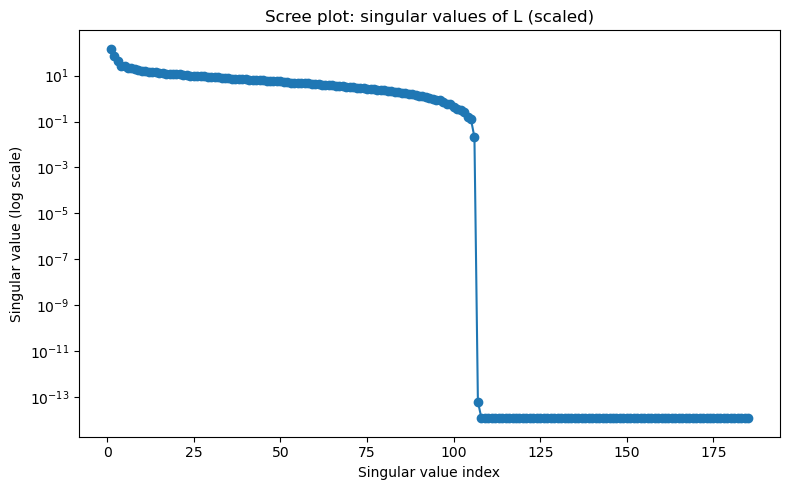

<Figure size 640x480 with 0 Axes>

In [111]:
%run plot_scree_L_scaled.py

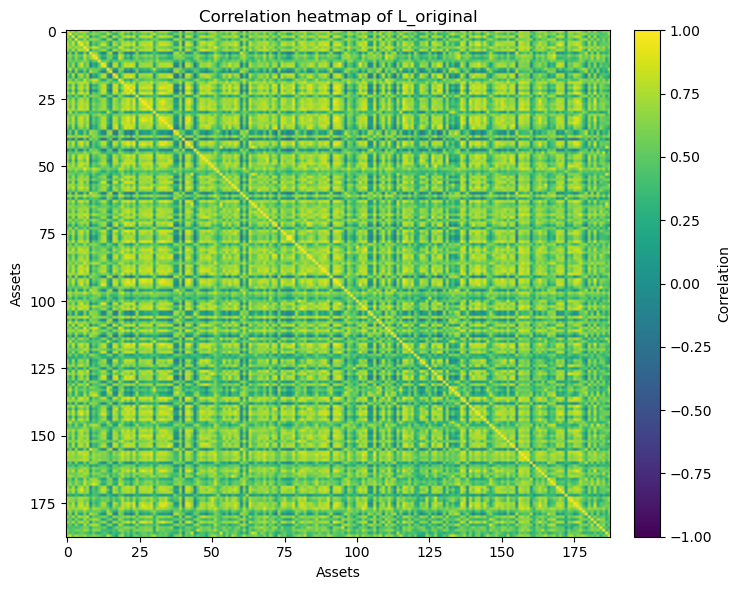

<Figure size 640x480 with 0 Axes>

In [112]:
%run plot_corr_L0.py

## III.4) Список результатов после R-PCA

- 1) `L_scaled.parquet` := 𝐿. Это низкоранговая компонента из ADMM прямо в масштабе $X_{cs}$:
$$X_{cs} = L + S$$
- 2) `S_scaled.parquet` := 𝑆. Это разрежённая компонента в том же масштабе.

Эти два файла — то, что непосредственно выходит из итераций ADMM (SVT для 𝐿, soft-threshold для 𝑆).

Артефакты в «оригинальных единицах»

 - 3) `L_original.parquet` := $𝐿_0$. Обратное масштабирование по столбцам:
$$L_0 = L×D.$$
 - 4) `S_original.parquet` := $𝑆_0$. Аналогично:
$$S_0 = S×D.$$.

 - 5) `X_reconstructed_from_RPCA.parquet` := $𝑋_{recon}$. Полная обратная трансформация:
$$X_{recon} = L_0 + S_0 + 1m^⊤.$$

# IV Step 4.

[INFO] Condition numbers (annualized):
  cond(Sigma_L  = Cov(L))         : 14,672,385,544,211,597,312
  cond(Sigma_RPCA = Cov(L)+diag)  : 2,026

[INFO] Saved files:
  - Sigma_L_daily.parquet / Sigma_L.parquet / R_L.parquet
  - mu_L_daily.csv / mu_L_annual.csv
  - Sigma_RPCA_daily.parquet / Sigma_RPCA.parquet
  - Sigma_daily.parquet / Sigma.parquet  (markowitz-compatible)


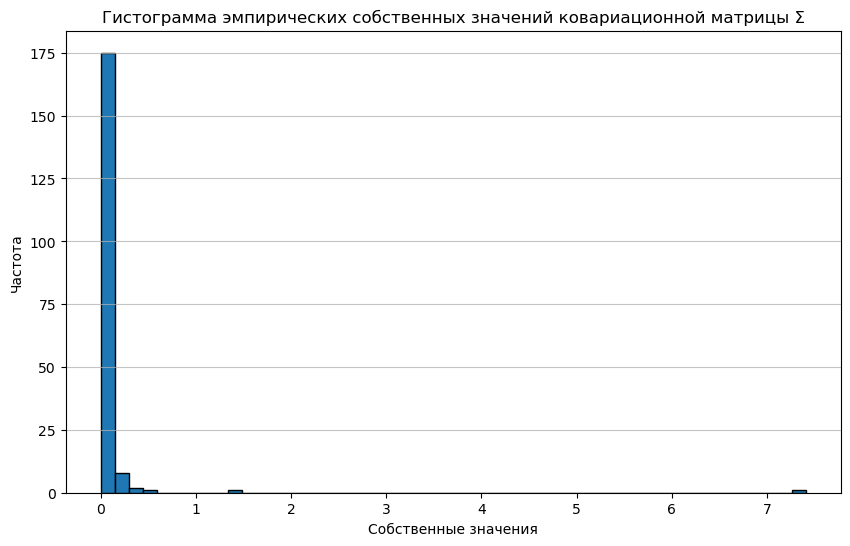

<Figure size 640x480 with 0 Axes>

In [113]:
%run rpca_step4_covariance.py

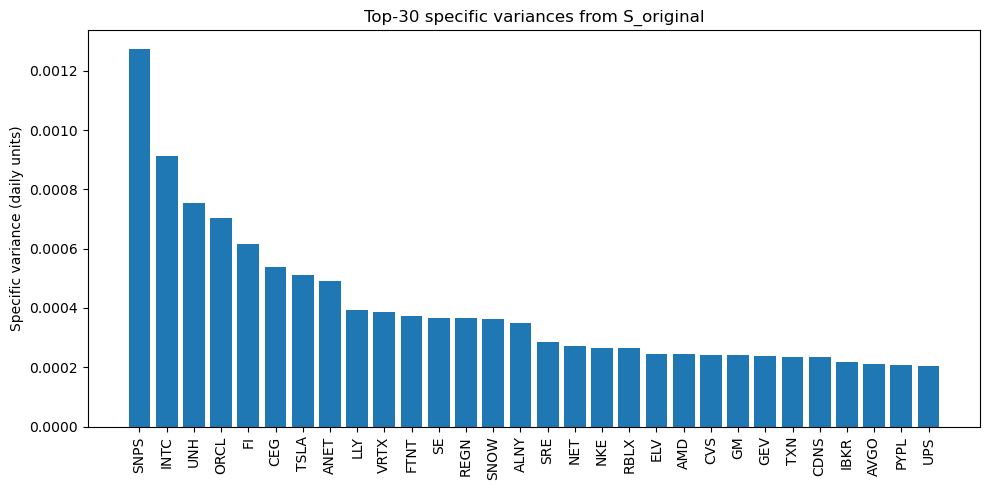

<Figure size 640x480 with 0 Axes>

In [114]:
%run plot_specific_variance_bar.py

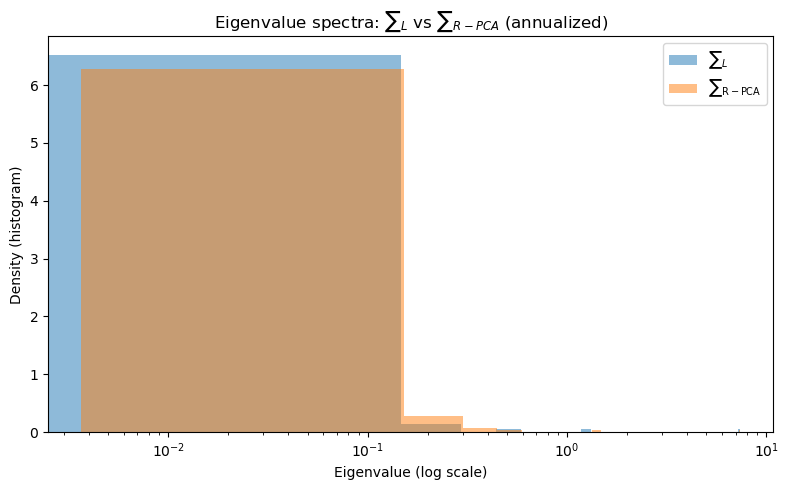

<Figure size 640x480 with 0 Axes>

In [115]:
%run plot_eig_hist_SigmaL_vs_SigmaRPCA.py

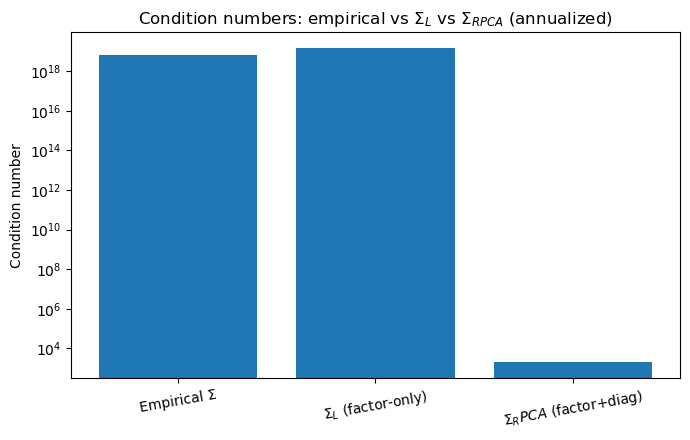

<Figure size 640x480 with 0 Axes>

In [116]:
%run plot_condition_numbers_bar.py

## IV.1) Построение ковариационной матрицы на основе R-PCA

- IV.1.1) Факторная ковариация:$Σ_L = Cov(L_0).$
- IV.1.2) Специфические дисперсии: $𝜎_{spec,𝑖}^2 = Var(E_{⋅,𝑖}), E = (X − 1m^⊤) − L_0 = S_0.$.
- IV.1.3) Итоговая ковариация RPCA: $Σ_{RPCA} = Σ_𝐿 + diag(𝜎_{spec}^2).$

## IV.2) Сохранённые результаты (из rpca_step4_covariance.py).
- `Sigma_L_daily.parquet` ↔ $Σ_𝐿$ на дневном масштабе;
- `Sigma_L.parquet` ↔ $Σ_𝐿 × 252$
- `R_L.parquet` ↔ корреляционная матрица $𝑅_𝐿 = Corr(𝐿_0)$;
- `mu_L_daily.csv` ↔ $𝜇_𝐿 = \mathbb{E}[𝐿_0]_{daily}$ ;
- `mu_L_annual.csv` ↔ $𝜇_𝐿 × 252$;
- `Sigma_RPCA_daily.parquet` ↔ $Σ_{RPCA}$ на дневном масштабе;
- `Sigma_RPCA.parquet` ↔ $Σ_{RPCA} × 252$;
- `Sigma_daily.parquet` и `Sigma.parquet` — это просто дубликаты из п. 4.2.4 с «markowitz-friendly» именами, чтобы мой оптимизатор читал «активную» матрицу без перемаппинга имён.

## IV.3 Важно! (хотя и ни фига не понятно)

Без этого шага оптимизатор портфеля не работает корректно!

4.3) Почему нельзя использовать только $Σ_𝐿$  для оптимального портфеля, и **нужно** $Σ_{R-PCA} = Σ_𝐿 + diag(𝜎_{spec}^2)$.

- IV.3.1) Теоретический аргумент: $𝐿_0$ — факторная часть; в ней «специфика» каждого актива выжата в $𝑆_0$. Следовательно, $Σ_𝐿$ систематически недооценивает риск (нет idiosyncratic), и часто имеет малые собственные значения ⇒ $Σ_𝐿$ плохо обусловлена.
- IV.3.2) Практическая диагностика в коде: скрипт печатает $cond(Σ_𝐿)$  и $cond(Σ_{R-PCA})$; опытно $cond(Σ_{R-PCA})$ на порядки лучше, что и делает задачу Марковица численно устойчивой.
- IV.3.3) Идентичность $E = (X − 1m^⊤) − L_0 = S_0.$ показывает, что диагональ $Var(𝐸)$ — именно «недостающий» специфический риск: добавление этой диагонали — минимальная правка, которая чинит обусловленность, не ломая факторную структуру.

# V. Заключение

Было:

Condition number cond(Σ):     6,921,184,743,310,157,824


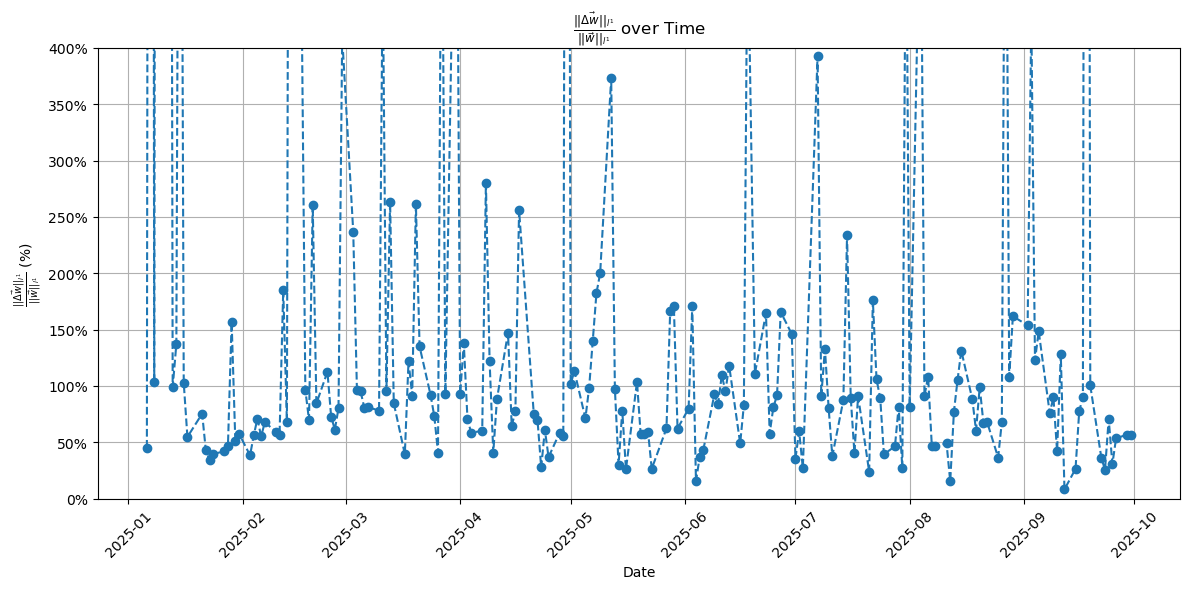

<Figure size 640x480 with 0 Axes>

In [117]:
%run "../Make-Up/markowitz_portfolio.py"

Стало:

[INFO] cond(Σ_RPCA): 2,026


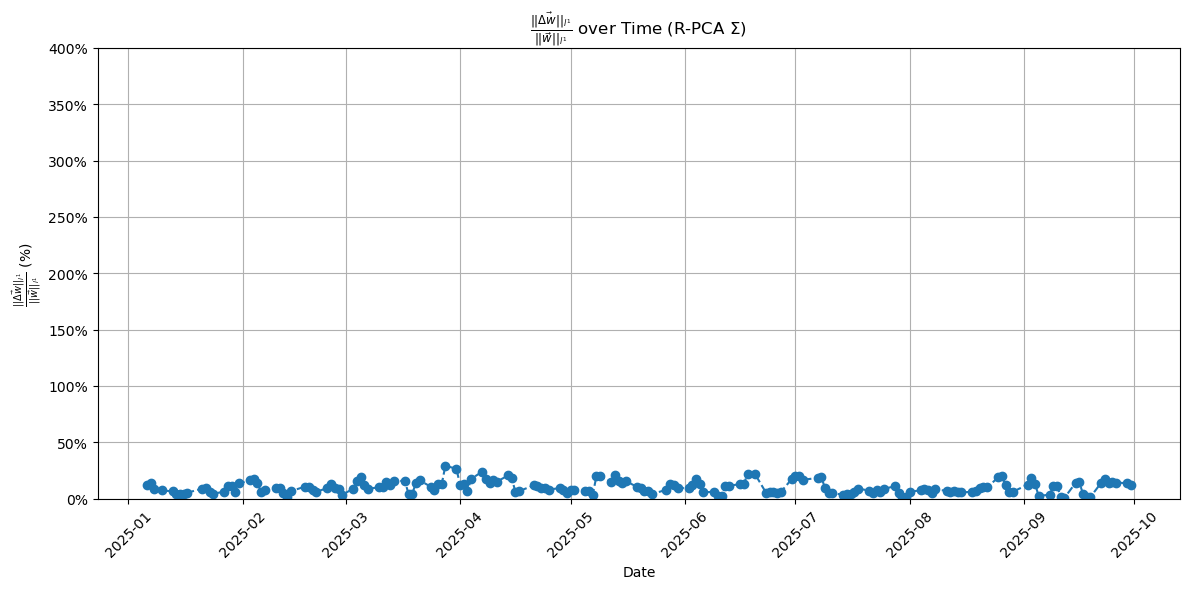

<Figure size 640x480 with 0 Axes>

In [118]:
%run markowitz_portfolio_R_PCA_step5.py